In [1]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00


In [2]:
pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.7 MB/s eta 0:00:00


In [21]:
#Practical 1- Bernstein Vazirani Algorithm
from qiskit import QuantumCircuit
from qiskit_aer import Aer
# Hidden string
s = "110"
n = len(s)
# Create a circuit with n input qubits + 1 ancilla
qc = QuantumCircuit(n + 1, n)
# Step 1: Set ancilla qubit to | 1>
qc.x(n)
# Step 2: Apply Hadamard to all qubits
qc.h(range(n + 1))
# Step 3: Oracle (CNOTs where s = 1)
for i in range(n):
  if s[n - 1 - i] == '1':
    qc.cx(i, n)
# Step 4: Apply Hadamard again to input qubits
qc.h(range(n))
# Step 5: Measure input qubits
qc.measure(range(n), range(n))
# Run the circuit
backend = Aer.get_backend('qasm_simulator' )
result = backend.run(qc, shots=1024).result ()
print(result.get_counts())

{'110': 1024}


Measurement Results: {'11': 242, '00': 244, '10': 268, '01': 270}


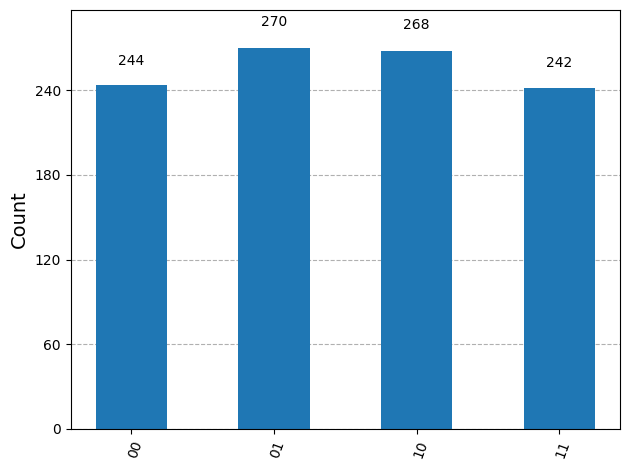

In [23]:
#Practical 2- Simon's Algorithm for Hidden string
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
n = 2
qc = QuantumCircuit(2*n, n)
for i in range(n):
  qc.h(i)
for i in range(n):
  qc.cx(i, i+n)
  qc.cx(0, n)
  qc.cx(1, n+1)
for i in range(n):
  qc.h(i)
for i in range(n):
  qc.measure(i, i)
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result ()
counts = result.get_counts ()
print("Measurement Results:", counts)
plot_histogram(counts)

Measurement Results: {'11': 1024}


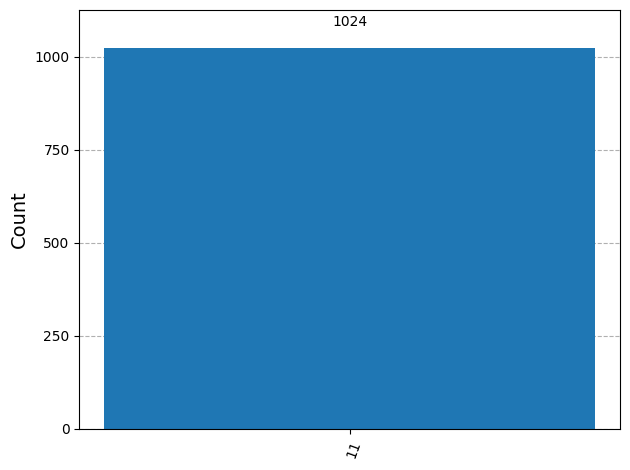

In [25]:
#Practical 3- Grover's Search Algorithm
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
# Create 2-qubit circuit
qc = QuantumCircuit(2, 2)
# Step 1: Apply Hadamard to create superposition
qc.h([0, 1])
# Step 2: Oracle (mark | 11>)
qc.cz(0, 1)
# Step 3: Diffusion Operator
qc.h([0, 1])
qc.x([0, 1])
qc.cz(0, 1)
qc.x([0, 1])
qc.h([0, 1])
# Step 4: Measure
qc.measure([0,1], [0,1])
# Execute
simulator = Aer.get_backend('qasm_simulator')
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts ()
print("Measurement Results:", counts)
plot_histogram(counts)

In [27]:
#Practical 4- Extension of Grover's search for 3-qubit
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
# Number of qubits
n = 3
iterations = 2  # Optimal number of Grover iterations for 3 qubits
# Create quantum circuit with n qubits and n classical bits
qc = QuantumCircuit(n, n)
# Step 1: Apply Hadamard gates to all qubits (create superposition)
qc.h(range(n))
# Define the oracle for |101>
def oracle(qc):
    # Flip the state |101> (qubits 0,1,2)
    qc.x(1)         # Flip qubit 1 to prepare |101>
    qc.cz(0,2)      # Controlled-Z between qubit 0 and qubit 2
    qc.x(1)         # Undo flip
# Define the diffusion operator (inversion about the mean)
def diffusion(qc):
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)  # Multi-controlled Toffoli
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
# Step 2: Apply Grover iterations
for _ in range(iterations):
    oracle(qc)
    diffusion(qc)
# Step 3: Measure all qubits
qc.measure(range(n), range(n))
# Step 4: Execute on simulator
simulator = Aer.get_backend('qasm_simulator')
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()
print("Measurement Results:", counts)

Measurement Results: {'100': 129, '010': 142, '000': 131, '011': 124, '111': 124, '101': 128, '110': 129, '001': 117}


In [30]:
#Practical 5-Quntum Forier Transform (QFT) and it's inverse
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
import importlib
try:
    import qiskit.visualization.circuit.matplotlib
    importlib.reload(qiskit.visualization.circuit.matplotlib)
except Exception:
    # This might happen if the module hasn't been loaded yet or other issues.
    pass
# Step 2: Define QFT Function
def qft(circuit, qubits):
    """Apply Quantum Fourier Transform on given qubits."""
    n = len(qubits)
    for j in range(n):
        circuit.h(qubits[j])
        for k in range(j+1, n):
            angle = np.pi / 2**(k-j)
            circuit.cp(angle, qubits[k], qubits[j])
    # Swap qubits to reverse order
    for i in range(n//2):
        circuit.swap(qubits[i], qubits[n-i-1])
# Step 3: Define Inverse QFT Function
def inverse_qft(circuit, qubits):
    """Apply inverse QFT on given qubits."""
    n = len(qubits)
    # Swap qubits first
    for i in range(n//2):
        circuit.swap(qubits[i], qubits[n-i-1])
    for j in reversed(range(n)):
        for k in reversed(range(j+1, n)):
            angle = -np.pi / 2**(k-j)
            circuit.cp(angle, qubits[k], qubits[j])
        circuit.h(qubits[j])
# Step 4: Create Quantum Circuit
n = 3  # number of qubits
qc = QuantumCircuit(n)
# Prepare input state |x> = |5> as an example
input_state = 5
for i in range(n):
  if (input_state >> i) & 1:
    qc.x(i)
print("Initial Circuit with input |5> prepared:")
display(qc.draw('text')) # Changed 'mpl' to 'text'
# Step 5: Apply QFT
qft(qc, list(range(n)))
print("Circuit after QFT applied:")
display(qc.draw('text')) # Changed 'mpl' to 'text'
# Step 6: Apply Inverse QFT
inverse_qft(qc, list(range(n)))
print("Circuit after Inverse QFT applied:")
display(qc.draw('text')) # Changed 'mpl' to 'text'
# Step 7: Measure All Qubits
qc.measure_all()
# Step 8: Execute on Simulator
backend = Aer.get_backend('qasm_simulator')
result = backend.run(qc, shots=1024).result()
counts = result.get_counts()
print("Measurement Result:", counts)

Initial Circuit with input |5> prepared:


┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
     ┌───┐
q_2: ┤ X ├
     └───┘

Circuit after QFT applied:


┌───┐┌───┐                                        
q_0: ┤ X ├┤ H ├─■────────■───────────────────────────X─
     └───┘└───┘ │P(π/2)  │       ┌───┐               │ 
q_1: ───────────■────────┼───────┤ H ├─■─────────────┼─
     ┌───┐               │P(π/4) └───┘ │P(π/2) ┌───┐ │ 
q_2: ┤ X ├───────────────■─────────────■───────┤ H ├─X─
     └───┘                                     └───┘

Circuit after Inverse QFT applied:


┌───┐┌───┐                                                               »
q_0: ┤ X ├┤ H ├─■────────■───────────────────────────X──X─────────────────────»
     └───┘└───┘ │P(π/2)  │       ┌───┐               │  │                ┌───┐»
q_1: ───────────■────────┼───────┤ H ├─■─────────────┼──┼───────■────────┤ H ├»
     ┌───┐               │P(π/4) └───┘ │P(π/2) ┌───┐ │  │ ┌───┐ │P(-π/2) └───┘»
q_2: ┤ X ├───────────────■─────────────■───────┤ H ├─X──X─┤ H ├─■─────────────»
     └───┘                                     └───┘      └───┘               »
«                         ┌───┐
«q_0: ─■─────────■────────┤ H ├
«      │         │P(-π/2) └───┘
«q_1: ─┼─────────■─────────────
«      │P(-π/4)                
«q_2: ─■───────────────────────
«

Measurement Result: {'101': 1024}


In [35]:
#Practical No 6- Shor's Algorithm for periodic factoring of small integers
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate # Changed QFT to QFTGate
from fractions import Fraction
from math import gcd
N, a, n_count = 15, 2, 8
# 1. Initialize Circuit (8 counting qubits, 4 target qubits)
qc = QuantumCircuit(n_count + 4, n_count)
qc.h(range(n_count)) # Set counting register to superposition
qc.x(n_count)        # Set target register to |1>
# 2. Apply Controlled Modular Exponentiation (2^x mod 15)
for q in range(n_count):
    U = QuantumCircuit(4)
    for _ in range(2**q):
        U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
    qc.append(U.to_gate().control(), [q] + list(range(n_count, n_count + 4)))
# 3. Apply Inverse QFT and Measure
qc.append(QFTGate(n_count).inverse(), range(n_count)) # Corrected to use .inverse() method
qc.measure(range(n_count), range(n_count))
sim = AerSimulator()
counts = sim.run(transpile(qc, sim), shots=1).result().get_counts()
measured_int = int(list(counts.keys())[0], 2)
# 4. Classical Post-Processing to Find Factors
r = Fraction(measured_int / (2**n_count)).limit_denominator(N).denominator
if r % 2 == 0 and r > 1:
    p = gcd(a**(r//2) - 1, N)
    q_factor = gcd(a**(r//2) + 1, N)
    print(f"Success! Period r={r}. Factors of {N} are {p} and {q_factor}.")
else:
    print(f"Trivial or odd period found (r={r}). Run the script again.")

Success! Period r=4. Factors of 15 are 3 and 5.


In [15]:
pip install qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 1.8 MB/s eta 0:00:00


In [36]:
#Practical 7- Quntum Support Vector (QSVM) classifier
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
# Qiskit Machine Learning imports
from qiskit.circuit.library import zz_feature_map # Changed from ZZFeatureMap to zz_feature_map
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
# --- 1. Generate and Preprocess Data ---
# Create a simple linearly separable synthetic dataset
X, y = make_classification(n_samples=40, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42)
# Scale features to the range (0, pi) - this is crucial because the data
# will be encoded as rotation angles on quantum gates.
X = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
# --- 2. Set up the Quantum Kernel ---
# Use a zz_feature_map function to encode classical data into quantum states
num_features = X.shape[1]
feature_map = zz_feature_map(feature_dimension=num_features, reps=2, entanglement='linear')
# Changed from ZZFeatureMap to zz_feature_map
# Use a statevector simulator to exactly evaluate the fidelity (similarity)
# between the encoded quantum states
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)
# Construct the quantum kernel
quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)
# --- 3. Create and Train the QSVC ---
print("Training the Quantum Support Vector Classifier... (this may take a moment)")
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)
# --- 4. Predict and Evaluate ---
y_pred = qsvc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"QSVC Classification Accuracy: {accuracy * 100:.2f}%")

Training the Quantum Support Vector Classifier... (this may take a moment)
QSVC Classification Accuracy: 90.00%


In [37]:
#Practical 8- Simulate BB84 Quantum key distribution protocol using Qiskit Circuit
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
# Number of qubits
n = 20
# Step 1: Alice generates random bits & bases
alice_bits = np.random.randint(2, size=n)
alice_bases = np.random.randint(2, size=n)  # 0 = Z, 1 = X
# Step 2: Encode qubits
circuits = []
for i in range(n):
    qc = QuantumCircuit(1, 1)
    # Encode bit
    if alice_bits[i] == 1:
        qc.x(0)
    # Encode basis
    if alice_bases[i] == 1:
        qc.h(0)
    qc.barrier()
    circuits.append(qc)
# Step 3: Bob chooses random bases
bob_bases = np.random.randint(2, size=n)
# Step 4: Bob measures
backend = AerSimulator()
results = []
for i in range(n):
    qc = circuits[i]
    if bob_bases[i] == 1:
        qc.h(0)
    qc.measure(0, 0)
    job = backend.run(qc, shots=1)
    counts = job.result().get_counts()
    measured_bit = int(list(counts.keys())[0])
    results.append(measured_bit)
# Step 5: Key Sifting (keep matching bases)
shared_key = []
print("Index | A_bit A_base | B_base | Result")
print("---------------------------------------")
for i in range(n):
  print(f"{i:5} |   {alice_bits[i]} {alice_bases[i]}   |   {bob_bases[i]}   |   {results[i]}")
  if alice_bases[i] == bob_bases[i]:
    shared_key.append(results[i])
# Final Key
print("\n Shared Key:", shared_key)

Index | A_bit A_base | B_base | Result
---------------------------------------
    0 |   0 1   |   0   |   0
    1 |   1 1   |   0   |   0
    2 |   0 0   |   1   |   1
    3 |   1 0   |   0   |   1
    4 |   1 0   |   1   |   0
    5 |   1 1   |   1   |   1
    6 |   1 1   |   0   |   1
    7 |   0 0   |   0   |   0
    8 |   0 0   |   1   |   0
    9 |   0 1   |   1   |   0
   10 |   1 0   |   0   |   1
   11 |   1 0   |   0   |   1
   12 |   0 0   |   0   |   0
   13 |   0 1   |   0   |   0
   14 |   0 1   |   1   |   0
   15 |   1 0   |   1   |   1
   16 |   1 1   |   0   |   0
   17 |   1 0   |   0   |   1
   18 |   1 0   |   1   |   1
   19 |   0 0   |   1   |   1

 Shared Key: [1, 1, 0, 0, 1, 1, 0, 0, 1]
